In [ ]:
import numpy as np

from core.multilayer_calc import simple_multiplex_network, compute_coarse_phase_diagram, compute_fine_phase_diagram, save_phase_diagram_npz, extract_unique_guesses
from core.multilayer_plot import plot_phase_diagram, plot_k_vs_gamma_with_insets


# Figure 8

We start by plotting coarse grained results

In [2]:
G, pos = simple_multiplex_network()
mu = 1.0

coarse_gamma = np.linspace(0.2, 1.0, 50)
coarse_beta = np.linspace(0.25, 2.0, 50)

coarse_results = compute_coarse_phase_diagram(G=G, gamma_values=coarse_gamma, beta_values=coarse_beta, mu=mu)

save_phase_diagram_npz("coarse_results_cube_mu1_seed0.npz", coarse_results)

Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!


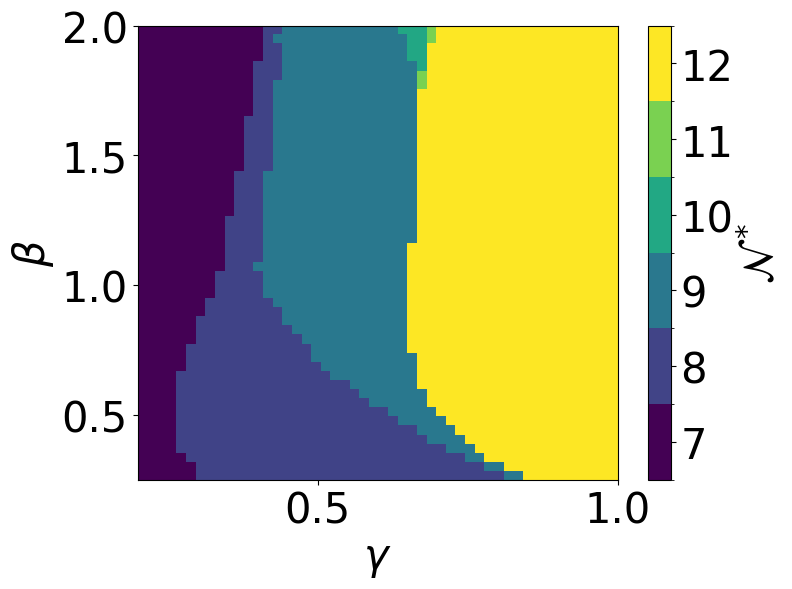

(<Figure size 800x600 with 2 Axes>,
 <Axes: xlabel='$\\gamma$', ylabel='$\\beta$'>)

In [3]:
plot_phase_diagram(gamma_values=coarse_results["gamma_values"], beta_values=coarse_results["beta_values"],
               num_nonzero_edges=coarse_results["num_nonzero_edges"])

Extract unique guesses from coarse grained results

In [5]:
unique_guesses = extract_unique_guesses(coarse_results["k_guesses"], atol=1e-2)
print(len(unique_guesses))

unique_guesses_array = np.vstack(unique_guesses)

np.savez("unique_guesses_cube_mu1_seed0.npz", unique_guesses=unique_guesses_array)

52


Using them as possible choices, we obtain a fine grained result

In [6]:
fine_gamma = np.linspace(0.2, 1.0, 250)
fine_beta = np.linspace(0.2, 2.0, 250)

fine_results = compute_fine_phase_diagram(G=G, gamma_values=fine_gamma, beta_values=fine_beta, mu=mu, unique_guesses=unique_guesses)

save_phase_diagram_npz("fine_results_cube_mu1_seed0.npz", fine_results)

Maximum number of repetitions reached!
Maximum number of repetitions reached!
Maximum number of repetitions reached!
[62500/62500] (249, 249)


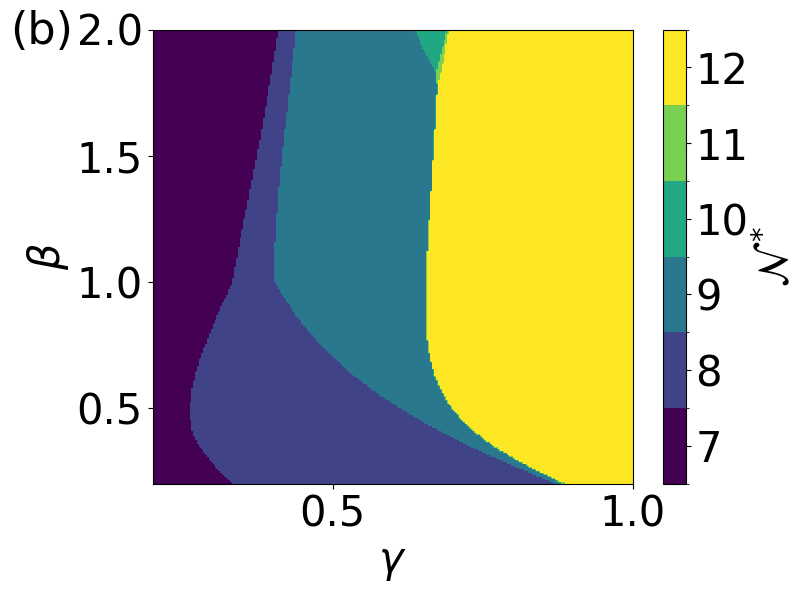

In [7]:
fig, ax = plot_phase_diagram(gamma_values=fine_results["gamma_values"], beta_values=fine_results["beta_values"],
               num_nonzero_edges=fine_results["num_nonzero_edges"], figtext=(0.0, 0.98, "(b)", 32), savepath="Fig8b_seed0.pdf")

Plot selected configurations for fixed $\beta = 0.6$

In [8]:
gamma_values_selected = np.linspace(0.2, 1.0, 500)
fig8a_data = compute_fine_phase_diagram(G=G, gamma_values=gamma_values_selected, beta_values=[0.6], mu=mu, unique_guesses=unique_guesses, verbose = False)

k_values_1d = [fig8a_data["k_values"][i, 0, :] for i in range(len(gamma_values_selected))]
num_nonzero_edges_1d = fig8a_data["num_nonzero_edges"][:, 0]

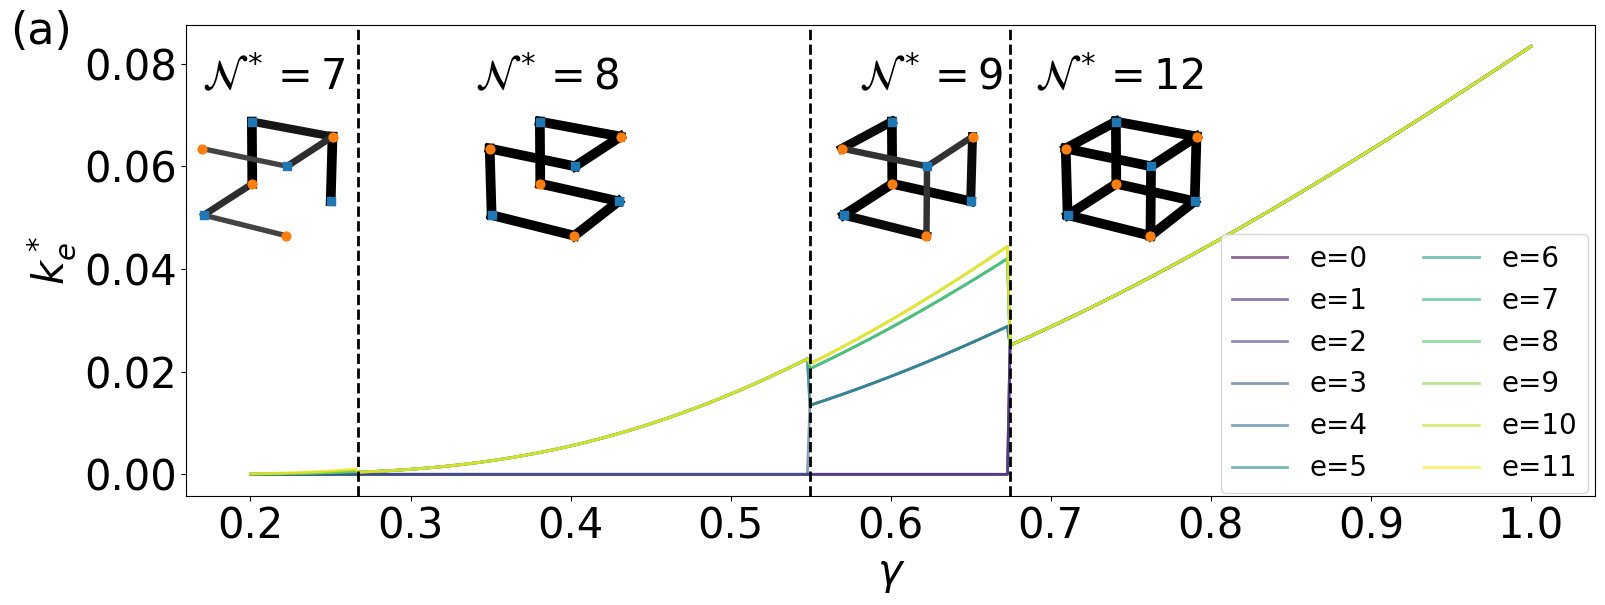

In [ ]:
phase_labels = [
        (0.17, 0.075, r"$\mathcal{N}^* = 7$", {"fontsize": 30}),
        (0.34, 0.075, r"$\mathcal{N}^* = 8$", {"fontsize": 30}),
        (0.58, 0.075, r"$\mathcal{N}^* = 9$", {"fontsize": 30}),
        (0.69, 0.075, r"$\mathcal{N}^* = 12$", {"fontsize": 30}),
    ]

inset_positions=[
        [0.1, 0.58, 0.12, 0.28],
        [0.28, 0.58, 0.12, 0.28],
        [0.5, 0.58, 0.12, 0.28],
        [0.64, 0.58, 0.12, 0.28],
    ]

inset_gammas=[0.2, 0.4, 0.6, 0.8]

fig, ax = plot_k_vs_gamma_with_insets(gamma_values=gamma_values_selected, k_values=k_values_1d, num_nonzero_edges=num_nonzero_edges_1d,
                            beta=0.7, mu=1.0, G=G, pos=pos, phase_labels= phase_labels, inset_positions=inset_positions,
                            inset_gammas=inset_gammas, savepath = "Fig8a_seed0.pdf")